# **IS 670 – Assignment 1**


## **Predicting Kick (Bad Buy) Vehicles Using Decision Trees**

### **Google Colab Setup**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import warnings
warnings.filterwarnings("ignore")

**1.Upload and clean data**

In [ ]:
# Read data
car_kick = pd.read_csv("/content/drive/MyDrive/IS670_data/car_kick.csv")
car_kick

,PurchDate,VehYear,VehicleAge,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,...,WheelTypeID,WheelType,Nationality,Size,TopThreeAmericanName,BYRNO,VNZIP1,VNST,IsOnlineSale,IsBadBuy
0,1289952000,2006,4,51954,6197,7062,9605,10426,5341,6351,...,2,Covers,AMERICAN,MEDIUM,CHRYSLER,99750,32124,FL,0,0
1,1242691200,2005,4,89127,3688,4783,4483,5666,3688,4783,...,2,Covers,AMERICAN,MEDIUM,FORD,20833,78754,TX,0,0
2,1248220800,2006,3,71271,6897,8449,7949,9625,6868,8549,...,1,Alloy,AMERICAN,LARGE,GM,22916,80011,CO,0,0
3,1285718400,2008,2,83338,7878,8925,11723,13026,7801,8704,...,2,Covers,AMERICAN,LARGE,GM,23657,94544,CA,0,0
4,1237334400,2007,2,58698,8800,10091,10004,11398,7355,8543,...,1,Alloy,AMERICAN,LARGE,GM,20833,77086,TX,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67206,1285804800,2008,2,56072,6255,6972,9852,10567,6326,7126,...,2,Covers,AMERICAN,MEDIUM,CHRYSLER,22808,77061,TX,0,1
67207,1274918400,2004,6,94232,8359,9645,12042,13302,7505,8188,...,1,Alloy,'TOP LINE ASIAN','MEDIUM SUV',OTHER,17675,28273,NC,0,1
67208,1280448000,2004,6,79534,2805,3826,6132,6871,3106,4479,...,1,Alloy,AMERICAN,MEDIUM,GM,18880,37771,TN,0,1
67209,1285200000,2003,7,79394,4042,5296,7335,8983,3534,4732,...,2,Covers,AMERICAN,'MEDIUM SUV',GM,23657,92337,CA,0,1


# **Predicting Kick (Bad Buy) Vehicles Using Decision Trees**

# **1. Business Understanding**

**Context**

Used car dealerships purchase vehicles at auctions to build their inventory. However, some of these vehicles later turn out to have serious mechanical defects, title issues, or other hidden problems. These vehicles, commonly referred to as “bad buys” or “kicks,” can lead to significant financial losses due to repair expenses, transportation costs, and reduced resale value.

The key business objective is to reduce the risk associated with these purchases. Since dealerships rely on historical auction data and limited vehicle information before making decisions, predictive analytics can provide valuable support. By identifying patterns associated with bad buys, a classification model can help flag high-risk vehicles before purchase, improving decision quality and reducing potential losses.

**Problem Statement**

The objective of this project is to develop a predictive model that determines whether a vehicle is likely to be a bad buy based on its available features.

Specifically, the goal is to use vehicle characteristics such as age, mileage, and pricing information to classify vehicles into risky and non-risky categories before they are purchased at auction.

**Framing the Problem as a Binary Classification Task**

This problem is formulated as a binary classification task because the target variable, Class, contains two possible outcomes:

Class = 1 → Bad Buy (risky vehicle)

Class = 0 → Good Buy (non-risky vehicle)

Using supervised learning, the model is trained on labeled historical data where the true class of each vehicle is known. The algorithm learns patterns that differentiate risky vehicles from safe ones and applies those patterns to new observations.

Because the target is binary and moderately imbalanced, evaluation metrics such as recall and F1-score are important in addition to accuracy, especially from a business risk perspective.

# **2. Data Understanding**

In [ ]:
car_kick.shape

(67211, 31)

In [ ]:
car_kick.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67211 entries, 0 to 67210
Data columns (total 31 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   PurchDate                          67211 non-null  int64 
 1   VehYear                            67211 non-null  int64 
 2   VehicleAge                         67211 non-null  int64 
 3   VehOdo                             67211 non-null  int64 
 4   MMRAcquisitionAuctionAveragePrice  67211 non-null  int64 
 5   MMRAcquisitionAuctionCleanPrice    67211 non-null  int64 
 6   MMRAcquisitionRetailAveragePrice   67211 non-null  int64 
 7   MMRAcquisitonRetailCleanPrice      67211 non-null  int64 
 8   MMRCurrentAuctionAveragePrice      67211 non-null  int64 
 9   MMRCurrentAuctionCleanPrice        67211 non-null  int64 
 10  MMRCurrentRetailAveragePrice       67211 non-null  int64 
 11  MMRCurrentRetailCleanPrice         67211 non-null  int64 
 12  VehB

In [ ]:
car_kick.describe()

,PurchDate,VehYear,VehicleAge,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,VehBCost,WarrantyCost,WheelTypeID,BYRNO,VNZIP1,IsOnlineSale,IsBadBuy
count,6.721100e+04,67211.000000,67211.000000,67211.000000,67211.000000,67211.000000,67211.000000,67211.000000,67211.000000,67211.000000,67211.000000,67211.000000,67211.000000,67211.000000,67211.000000,67211.000000,67211.000000,67211.000000,67211.000000
mean,1.263166e+09,2005.352606,4.168588,71734.558971,6162.054589,7411.975123,8538.503787,9895.922423,6166.708827,7429.722307,8817.942123,10189.606300,6754.219919,1278.942301,1.493386,26442.985419,58272.452768,0.025055,0.095461
std,1.820779e+07,1.727873,1.707501,14387.245482,2452.884994,2714.884242,3154.090485,3384.033541,2426.946652,2678.289955,3086.591314,3305.531489,1743.710847,579.077788,0.521232,25937.611063,26117.388216,0.156295,0.293852
min,1.231114e+09,2001.000000,0.000000,5368.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1400.000000,462.000000,1.000000,835.000000,2764.000000,0.000000,0.000000
25%,1.247789e+09,2004.000000,3.000000,62163.000000,4311.000000,5456.500000,6319.000000,7525.500000,4311.000000,5468.000000,6565.000000,7822.000000,5470.000000,853.000000,1.000000,17212.000000,32124.000000,0.000000,0.000000
50%,1.264032e+09,2005.000000,4.000000,73530.000000,6163.000000,7380.000000,8498.000000,9868.000000,6130.000000,7390.000000,8811.000000,10175.000000,6750.000000,1169.000000,1.000000,19662.000000,74135.000000,0.000000,0.000000
75%,1.279152e+09,2007.000000,5.000000,82530.000000,7806.000000,9049.000000,10709.500000,12153.500000,7776.000000,9045.000000,10972.000000,12370.000000,7910.000000,1623.000000,2.000000,22808.000000,80022.000000,0.000000,0.000000
max,1.293667e+09,2010.000000,9.000000,115717.000000,35722.000000,36859.000000,39080.000000,40308.000000,35722.000000,36859.000000,39080.000000,40308.000000,35900.000000,7498.000000,3.000000,99761.000000,99224.000000,1.000000,1.000000


## **Dataset Overview**

The dataset contains historical auction records with multiple predictor variables describing vehicle characteristics and pricing information. These include numerical variables such as vehicle age, odometer reading, and acquisition price, as well as categorical variables such as vehicle make, model, and auction details.

The dataset includes a large number of observations, which supports reliable model training and testing. Initial inspection revealed the presence of missing values and mixed data types, indicating that preprocessing steps were necessary before modeling.

In [ ]:
car_kick['IsBadBuy'].value_counts()

,count
IsBadBuy,
0,60795
1,6416


In [ ]:
car_kick['IsBadBuy'].value_counts(normalize=True)

,proportion
IsBadBuy,
0,0.904539
1,0.095461


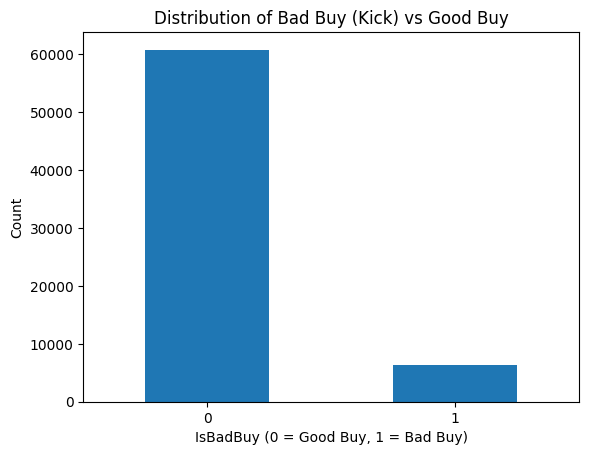

In [ ]:
import matplotlib.pyplot as plt

car_kick['IsBadBuy'].value_counts().plot(kind='bar')
plt.title("Distribution of Bad Buy (Kick) vs Good Buy")
plt.xlabel("IsBadBuy (0 = Good Buy, 1 = Bad Buy)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [ ]:
car_kick['IsBadBuy'].value_counts(normalize=True) * 100

,proportion
IsBadBuy,
0,90.453944
1,9.546056


## **Target Variable Analysis**

The target variable, Class, indicates whether a vehicle was ultimately identified as a bad buy. Since this variable has two categories, it is appropriate for classification modeling.

An analysis of the target distribution shows moderate class imbalance. Because of this, relying solely on accuracy may not provide a complete view of model performance. Metrics such as recall and F1-score are particularly important to ensure that risky vehicles are properly identified.

## **Univariate Analysis**

**VehicleAge Distribution**

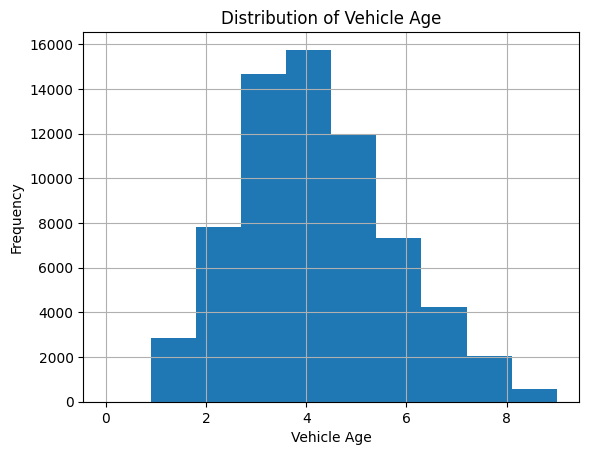

In [ ]:
plt.figure()
car_kick['VehicleAge'].hist()
plt.title("Distribution of Vehicle Age")
plt.xlabel("Vehicle Age")
plt.ylabel("Frequency")
plt.show()

**Vehicle Age**

**What does the distribution show?**
Most vehicles fall within a moderate age range, with fewer very new or very old cars. The distribution is slightly right-skewed.

**Why does this matter?**
Older vehicles may carry higher mechanical risk, while newer vehicles are less common due to higher purchase costs.

**Model implication:**
Vehicle age is likely an important predictor of bad buy risk.

**Odometer Distribution**

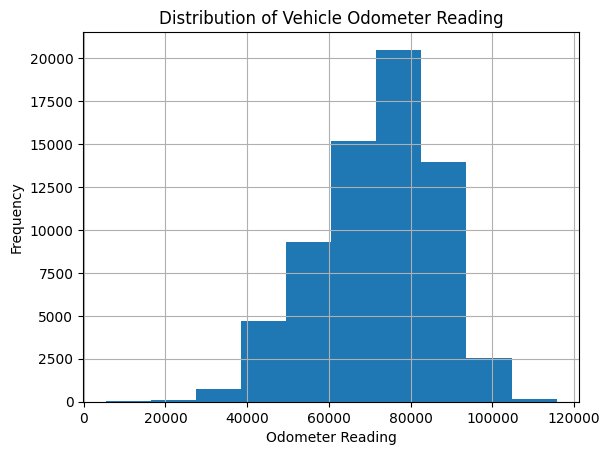

In [ ]:
plt.figure()
car_kick['VehOdo'].hist()
plt.title("Distribution of Vehicle Odometer Reading")
plt.xlabel("Odometer Reading")
plt.ylabel("Frequency")
plt.show()

**Odometer Reading**

**How is mileage distributed?**
Most vehicles have moderate to high mileage, with a small number showing extremely high values. The distribution is right-skewed.

**Business meaning:**
Higher mileage may indicate greater wear and potential mechanical issues.

**Model implication:**
Odometer reading is expected to contribute significantly to risk prediction.

<Figure size 640x480 with 0 Axes>

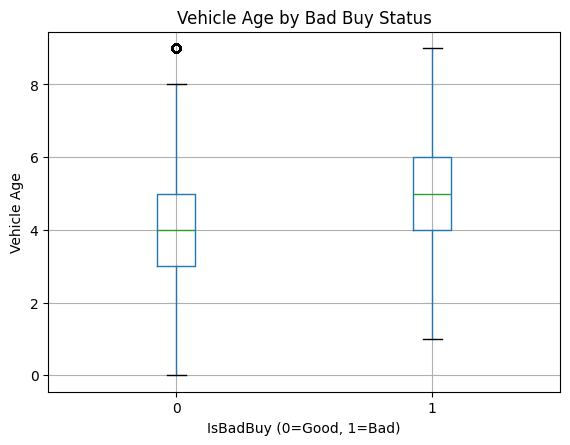

In [ ]:
plt.figure()
car_kick.boxplot(column='VehicleAge', by='IsBadBuy')
plt.title("Vehicle Age by Bad Buy Status")
plt.suptitle("")
plt.xlabel("IsBadBuy (0=Good, 1=Bad)")
plt.ylabel("Vehicle Age")
plt.show()

**Vehicle Age vs Bad Buy**

The boxplot shows that vehicles classified as bad buys generally have a slightly higher median age than good buys. The distribution for bad buys is shifted toward older vehicles.

This suggests that older vehicles may carry greater purchase risk due to increased wear and potential hidden issues. Therefore, VehicleAge is likely an important predictor in the classification model.

**Odometer vs Bad Buy**

<Figure size 640x480 with 0 Axes>

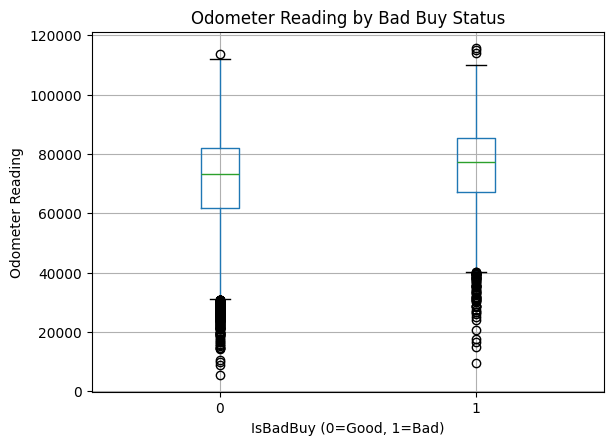

In [ ]:
plt.figure()
car_kick.boxplot(column='VehOdo', by='IsBadBuy')
plt.title("Odometer Reading by Bad Buy Status")
plt.suptitle("")
plt.xlabel("IsBadBuy (0=Good, 1=Bad)")
plt.ylabel("Odometer Reading")
plt.show()

**VehBCost Distribution**

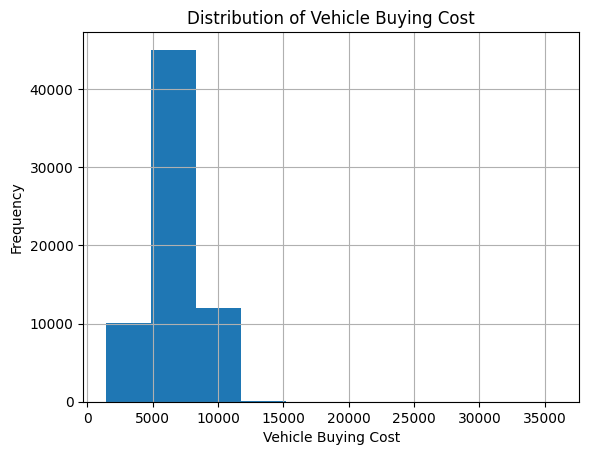

In [ ]:
plt.figure()
car_kick['VehBCost'].hist()
plt.title("Distribution of Vehicle Buying Cost")
plt.xlabel("Vehicle Buying Cost")
plt.ylabel("Frequency")
plt.show()

**VehBCost vs Bad Buy**

<Figure size 640x480 with 0 Axes>

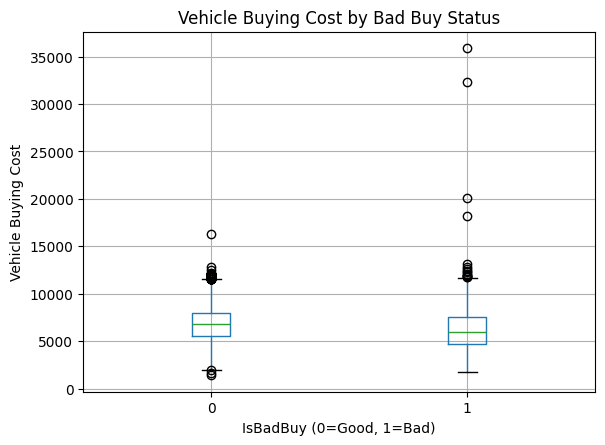

In [ ]:
plt.figure()
car_kick.boxplot(column='VehBCost', by='IsBadBuy')
plt.title("Vehicle Buying Cost by Bad Buy Status")
plt.suptitle("")
plt.xlabel("IsBadBuy (0=Good, 1=Bad)")
plt.ylabel("Vehicle Buying Cost")
plt.show()

**Kick Rate by Transmission**

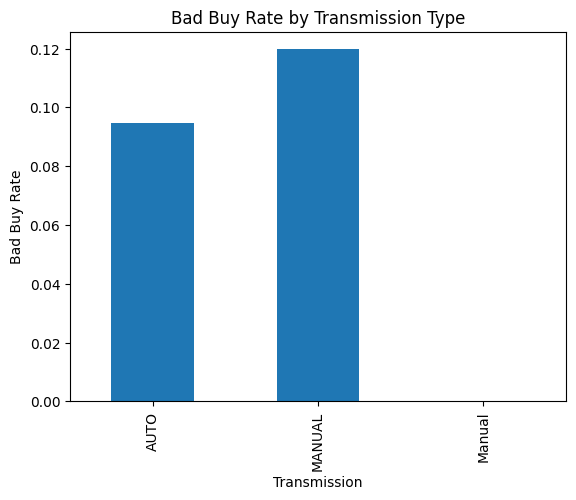

In [ ]:
kick_rate_trans = car_kick.groupby('Transmission')['IsBadBuy'].mean()

kick_rate_trans.plot(kind='bar')
plt.title("Bad Buy Rate by Transmission Type")
plt.ylabel("Bad Buy Rate")
plt.show()

**Auction Type Analysis**

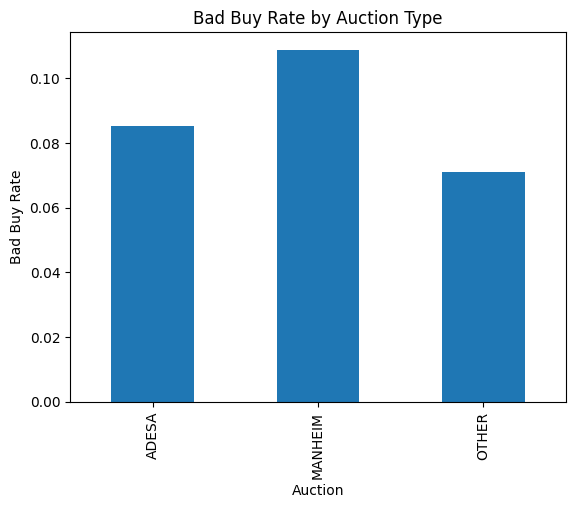

In [ ]:
kick_rate_auction = car_kick.groupby('Auction')['IsBadBuy'].mean()

kick_rate_auction.plot(kind='bar')
plt.title("Bad Buy Rate by Auction Type")
plt.ylabel("Bad Buy Rate")
plt.show()

**Correlation Heatmap**

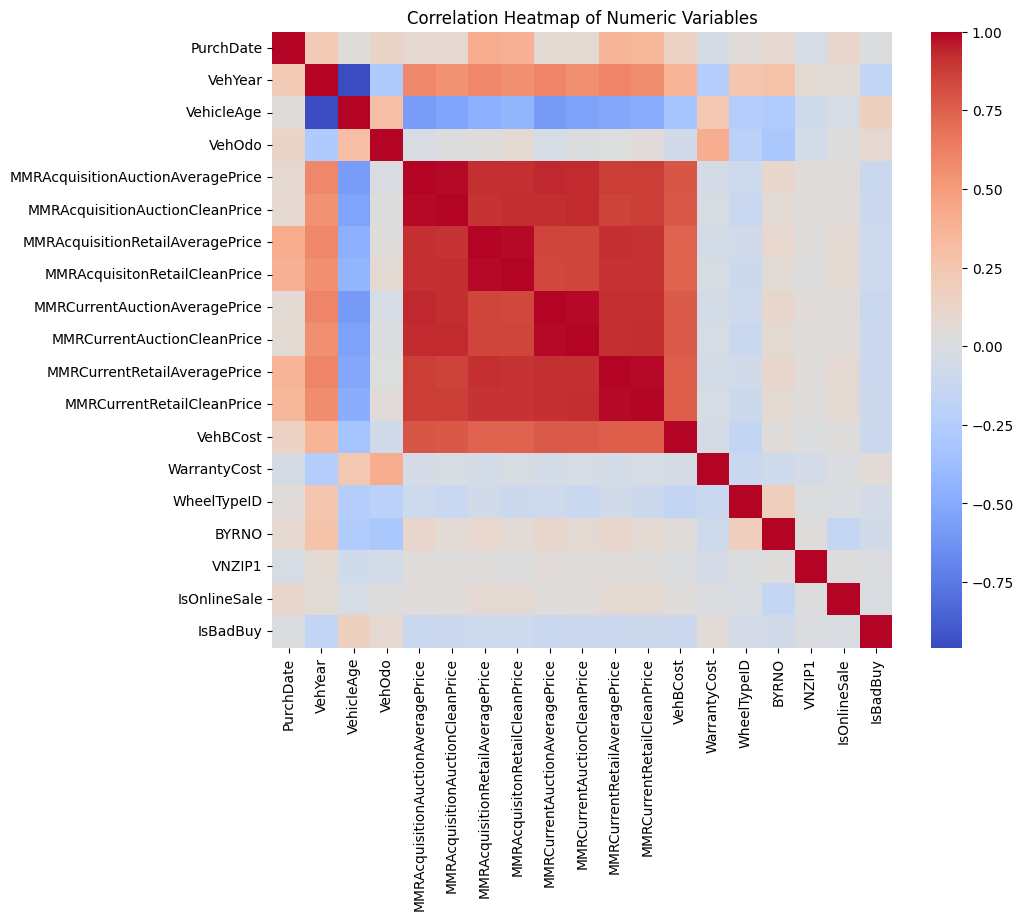

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,8))
numeric_car_kick = car_kick.select_dtypes(include=['int64'])
sns.heatmap(numeric_car_kick.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

# **Data Preparation**

In [ ]:
car_kick['PurchDate'].head()

,PurchDate
0,1289952000
1,1242691200
2,1248220800
3,1285718400
4,1237334400


**Fix Variable Types**

In [ ]:
car_kick['PurchDate'] = pd.to_datetime(car_kick['PurchDate'], unit='s')
car_kick['PurchDate'].head()

,PurchDate
0,2010-11-17
1,2009-05-19
2,2009-07-22
3,2010-09-29
4,2009-03-18


The variable PurchDate was initially stored as a numeric Unix timestamp, representing the number of seconds since 1970. It was converted into a proper datetime format using pandas to ensure accurate time representation.

Converting the date improves data quality and allows for meaningful time-based analysis or future feature engineering if needed.

**Class Imbalance Discussion**

The target variable IsBadBuy is significantly imbalanced. A large majority of vehicles are classified as good purchases, while only a small percentage are labeled as bad buys.

This imbalance can distort model evaluation. For example, a model that predicts every vehicle as a good purchase would achieve high overall accuracy, yet it would fail to identify any risky vehicles. Therefore, accuracy alone is not an adequate measure of performance in this case.

To better assess the model’s effectiveness, metrics such as precision, recall, F1-score, and the confusion matrix provide more meaningful insight into how well the model detects bad buys.

In more advanced applications, techniques such as oversampling (e.g., SMOTE), undersampling, or adjusting class weights could be used to address class imbalance. However, for the purpose of this assignment, the original class distribution will be maintained.

**Prepare Data for Modeling**

**Dummy Coding**

In [ ]:
# Drop PurchDate (not useful for prediction)
car_kick_model = car_kick.drop(columns=['PurchDate'])

# Separate target
X = car_kick_model.drop(columns=['IsBadBuy'])
y = car_kick_model['IsBadBuy']

print(X.shape)
print(y.shape)

(67211, 29)
(67211,)


In [ ]:
X = pd.get_dummies(X, drop_first=True)
X.shape

(67211, 2028)

All categorical variables were transformed into numerical form using one-hot encoding. Because several features (such as vehicle model, make, and state) contain many distinct categories, the encoding process substantially increased the number of predictor variables.

As a result, the final feature matrix consists of 2,028 predictors.

This transformation ensures that the data is compatible with machine learning algorithms, including Decision Trees, which require numerical inputs for modeling.

**Train/Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(53768, 2028)
(13443, 2028)


**Build Baseline Decision Tree**

In [163]:
from sklearn.tree import DecisionTreeClassifier

# Baseline model
car_kick = DecisionTreeClassifier(random_state=42)

car_kick.fit(X_train, y_train)

# Predictions
y_pred = car_kick.predict(X_test)

**Evaluate the Model**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("\nConfusion Matrix:\n", cm)

Accuracy: 0.8348582905601428
Precision: 0.15424354243542435
Recall: 0.16289945440374123
F1 Score: 0.15845337376800606

Confusion Matrix:
 [[11014  1146]
 [ 1074   209]]


The baseline Decision Tree achieved an accuracy of 83.5%. However, due to class imbalance, accuracy alone is not sufficient to evaluate performance.

Precision (15.4%) and recall (16.3%) for detecting bad buys are low, indicating poor identification of the minority class. The low F1-score (0.158) further confirms weak performance.

These results suggest the baseline model requires tuning, particularly adjusting the tree depth, to improve detection of bad buys.

**Tune Tree Depth**

In [ ]:
depths = [2, 3, 4, 5, 6, 8, 10, 15]

results = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([d, accuracy, precision, recall, f1])

results_car_kick= pd.DataFrame(results, columns=["Depth", "Accuracy", "Precision", "Recall", "F1"])
results_car_kick

,Depth,Accuracy,Precision,Recall,F1
0,2,0.904560,0.000000,0.000000,0.000000
1,3,0.904560,0.000000,0.000000,0.000000
2,4,0.904634,0.600000,0.002338,0.004658
3,5,0.904114,0.363636,0.006235,0.012261
4,6,0.904411,0.437500,0.005456,0.010778
5,8,0.901956,0.278481,0.017147,0.032305
6,10,0.899799,0.257576,0.026500,0.048057
7,15,0.891840,0.249267,0.066251,0.104680


**Build Final Model (Depth = 15)**

In [ ]:
best_model = DecisionTreeClassifier(max_depth=15, random_state=42)
best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
recall = recall_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)
cm = confusion_matrix(y_test, y_pred_best)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("\nConfusion Matrix:\n", cm)

Accuracy: 0.8918396191326341
Precision: 0.24926686217008798
Recall: 0.06625097427903351
F1 Score: 0.10467980295566502

Confusion Matrix:
 [[11904   256]
 [ 1198    85]]


The confusion matrix shows that most good purchases are correctly classified, but many bad buys are still misclassified as good purchases. This explains the low recall for the minority class.

**Model Tuning (max_depth)**

To improve performance, decision trees with varying depths were evaluated. Very shallow trees (depth 2–6) were unable to effectively identify bad buys, resulting in extremely low recall and F1-scores.

This behavior reflects the bias–variance tradeoff: shallow trees are too simple and underfit the data, while deeper trees capture more patterns but risk overfitting. Selecting an appropriate depth helps balance model complexity and generalization.

As the depth increased, the model began detecting more bad buys. The best overall performance was observed at max_depth = 15, achieving:

Accuracy: 0.8918

Precision: 0.2493

Recall: 0.0663

F1-score: 0.1047

Although recall remains relatively low, depth 15 provides the best tradeoff between identifying bad buys and maintaining overall accuracy. Therefore, the model with max_depth = 15 was selected as the final model.

The model was selected based on the highest test F1-score, as it provides a better balance between precision and recall in an imbalanced dataset.

**Feature Importance**

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
1,VehicleAge,0.108997
11,VehBCost,0.086120
2,VehOdo,0.082718
15,VNZIP1,0.045928
3,MMRAcquisitionAuctionAveragePrice,0.037047
7,MMRCurrentAuctionAveragePrice,0.035259
10,MMRCurrentRetailCleanPrice,0.034171
4,MMRAcquisitionAuctionCleanPrice,0.032873
14,BYRNO,0.032458
8,MMRCurrentAuctionCleanPrice,0.030735


**Key Variables Influencing Prediction**

The feature importance results indicate that the strongest predictors of bad buys include:

VehicleAge – Older vehicles show a higher likelihood of being classified as bad buys.

VehBCost – Lower acquisition costs appear to be associated with increased risk.

VehOdo – Higher mileage contributes to greater mechanical uncertainty.

VNZIP1 – Geographic location may reflect differences in vehicle condition or seller reliability.

MMR price-related variables – Market valuation measures play an important role in identifying potential risk.

These findings align with practical business reasoning. Vehicles that are older, driven more extensively, and purchased at lower prices are more likely to contain hidden mechanical or quality issues. Additionally, regional factors and auction conditions may influence sourcing quality.

The significance of multiple market price indicators further confirms that valuation discrepancies are central to predicting problematic purchases.

# **Evaluation**

**How the Model Addresses the Business Problem**

The final Decision Tree model (max_depth = 15) is designed to predict whether a vehicle purchased at auction is likely to be a bad buy. This model can be used as a decision-support tool during the bidding process to assess the risk level of each vehicle.

If a vehicle is classified as high risk, the dealership could choose to:

Avoid purchasing the vehicle,

Submit a more cautious bid, or

Perform additional inspection before finalizing the purchase.

By incorporating this predictive insight into the purchasing process, dealerships can reduce potential financial losses and maintain higher inventory quality.

**Practicality and Limitations**

Although the model offers meaningful insights, several limitations should be acknowledged.

The recall for detecting bad buys is relatively low (6.6%), indicating that many risky vehicles are not identified by the model. The strong class imbalance further makes it challenging to accurately detect the minority class. In addition, certain external factors—such as undisclosed mechanical damage—may not be fully captured in the available data.

Despite these limitations, the model still provides value by uncovering important risk patterns and highlighting key predictors, including vehicle age, mileage, and acquisition cost.

Future improvements could involve exploring ensemble methods such as Random Forest or Gradient Boosting, adjusting class weights, applying resampling techniques, or incorporating additional features related to vehicle condition.

# **Conclusion**

This project developed a Decision Tree model to predict whether a vehicle purchased at auction would become a bad buy. The analysis identified vehicle age, purchase cost, mileage, and pricing variables as key risk factors.

Although the model’s recall remains limited due to class imbalance, it successfully uncovers meaningful patterns associated with high-risk vehicles. The results demonstrate how machine learning can support more informed, data-driven decision-making in the used car auction industry. Further improvements, such as handling class imbalance or using ensemble models, could enhance predictive performance.

In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/IS670_Assignment1_SarkarPayel.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/IS670_Assignment1_SarkarPayel.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 10 image(s).
[NbConvertApp] Writing 808046 bytes to /content/drive/MyDrive/Colab Notebooks/IS670_Assignment1_SarkarPayel.html
